# Data Preprocessing File

The purpose of this preprocessing stage is to apply the transformations and feature engineering steps identified during the exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('train.csv')
validation = pd.read_csv('validation.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,delta_issue_earliest,term,emp_length,home_ownership,verification_status,purpose,initial_list_status
0,0,25000.0,19.20,153000.0,6.39,9.0,0.0,25599.0,49.6,21.0,1.0,0.0,3287,60 months,8 years,MORTGAGE,Verified,debt_consolidation,f
1,1,5000.0,13.67,43763.0,6.23,14.0,1.0,6784.0,45.8,38.0,0.0,1.0,8097,36 months,10+ years,OWN,Not Verified,car,w
2,0,20000.0,9.67,90000.0,11.36,16.0,0.0,5295.0,26.3,22.0,0.0,0.0,4536,36 months,3 years,RENT,Verified,debt_consolidation,f
3,0,9550.0,17.57,55000.0,24.85,9.0,0.0,7840.0,80.0,21.0,3.0,0.0,5479,36 months,4 years,MORTGAGE,Not Verified,debt_consolidation,f
4,0,20125.0,23.50,45000.0,29.71,14.0,1.0,13977.0,83.7,37.0,2.0,1.0,10074,60 months,2 years,OWN,Verified,credit_card,f


## 1. Log Transformation of the Numerical Variables
I apply a log transformation to the skewed variables annual_inc, revol_bal, and delta_issue_earliest to reduce skewness and improve their distributions

In [4]:
# np.log() generates some number of -inf due to division by 0. np.log1p() is applied instead
train[['annual_inc', 'revol_bal', 'delta_issue_earliest']] = np.log1p(train[['annual_inc', 'revol_bal', 'delta_issue_earliest']])
validation[['annual_inc', 'revol_bal', 'delta_issue_earliest']] = np.log1p(validation[['annual_inc', 'revol_bal', 'delta_issue_earliest']])
test[['annual_inc', 'revol_bal', 'delta_issue_earliest']] = np.log1p(test[['annual_inc', 'revol_bal', 'delta_issue_earliest']])

In [5]:
#checking for -inf
train[train['revol_bal'] == -np.inf]

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,delta_issue_earliest,term,emp_length,home_ownership,verification_status,purpose,initial_list_status


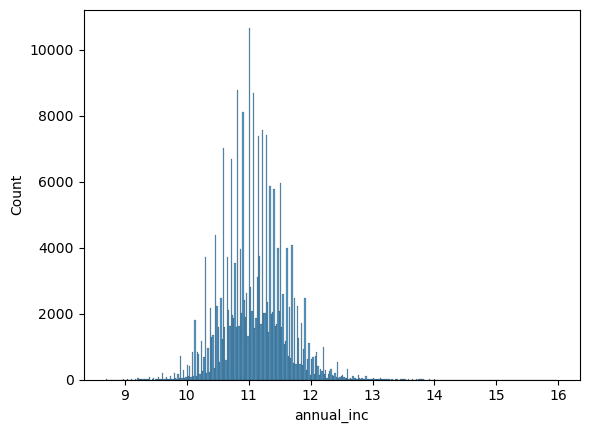

In [6]:
sns.histplot(data=train['annual_inc'])
plt.show()

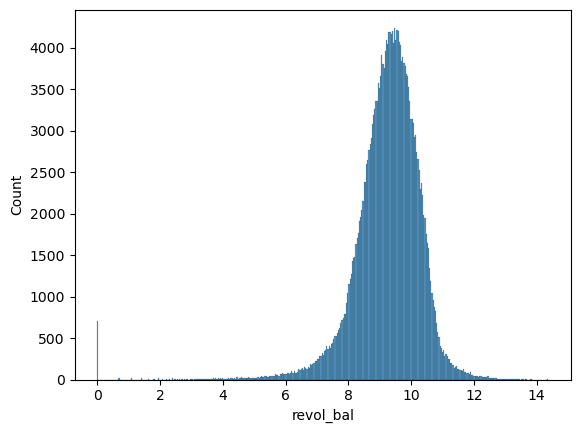

In [7]:
sns.histplot(data=train['revol_bal'])
plt.show()

The distribution looks nicer now

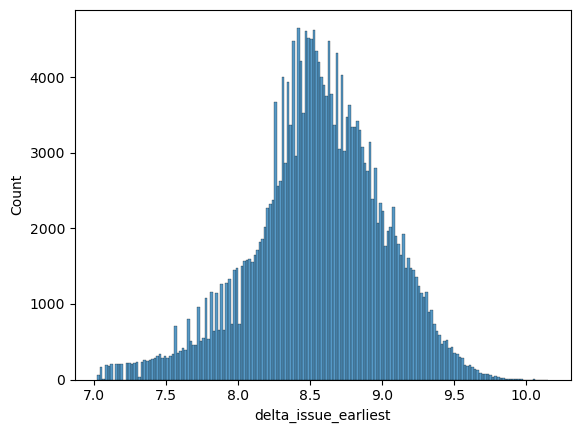

In [8]:
sns.histplot(data=train['delta_issue_earliest'])
plt.show()

## 2. Combining Sparse Categories
I combine sparse categories for variables home_ownership, purpose, emp_length to reduce sparsity and avoid creating low-frequency dummy variables

In [9]:
mapping_ho = {'OTHER': 'OTHERS', 'NONE': 'OTHERS', 'ANY':'OTHERS', 'MORTGAGE': 'MORTGAGE', 'OWN': 'OWN', 'RENT': 'RENT'}

In [10]:
train['home_ownership'] = train['home_ownership'].map(mapping_ho)
validation['home_ownership'] = validation['home_ownership'].map(mapping_ho)
test['home_ownership'] = test['home_ownership'].map(mapping_ho)
train['home_ownership'].value_counts()

home_ownership
MORTGAGE    121159
RENT         95109
OWN          22235
OTHERS          39
Name: count, dtype: int64

In [11]:
train['purpose'].value_counts()

purpose
debt_consolidation    145041
credit_card            51359
home_improvement       14017
other                  11484
major_purchase          4566
small_business          2640
medical                 2293
car                     2201
moving                  1546
vacation                1368
house                   1207
wedding                  656
renewable_energy         164
Name: count, dtype: int64

In [12]:
mapping_p = {'debt_consolidation': 'debt_consolidation', 'credit_card': 'credit_card', 
             'home_improvement': 'home_improvement', 'other':'other', 'major_purchase': 'consumer_needs',
            'small_business': 'consumer_needs', 'medical':'consumer_needs', 'car':'consumer_needs',
            'moving':'consumer_needs', 'vacation':'consumer_needs', 'house':'consumer_needs', 
            'wedding':'consumer_needs', 'renewable_energy':'consumer_needs' }

In [13]:
train['purpose'] = train['purpose'].map(mapping_p)
validation['purpose'] = validation['purpose'].map(mapping_p)
test['purpose'] = test['purpose'].map(mapping_p)
train['purpose'].value_counts()

purpose
debt_consolidation    145041
credit_card            51359
consumer_needs         16641
home_improvement       14017
other                  11484
Name: count, dtype: int64

In [14]:
train['emp_length'].value_counts()

emp_length
10+ years    82079
2 years      22150
3 years      19492
< 1 year     19341
5 years      16316
1 year       15946
4 years      14435
7 years      13297
6 years      13069
8 years      12478
9 years       9939
Name: count, dtype: int64

In [15]:
mapping_y = {'< 1 year': '<=2 years', '1 year': '<=2 years', '2 years': '<=2 years', 
             '3 years': '3-5 years', '4 years': '3-5 years', '5 years': '3-5 years',
             '6 years': '6-9 years', '7 years': '6-9 years', '8 years': '6-9 years', 
             '9 years':'6-9 years', '10+ years': '10+ years'}

In [16]:
train['emp_length'] = train['emp_length'].map(mapping_y)
validation['emp_length'] = validation['emp_length'].map(mapping_y)
test['emp_length'] = test['emp_length'].map(mapping_y)
train['emp_length'].value_counts()

emp_length
10+ years    82079
<=2 years    57437
3-5 years    50243
6-9 years    48783
Name: count, dtype: int64

## 3. Converting Variables into Binary
I transform the numerical variables mort_acc, pub_rec, pub_rec_bankruptcies into binary features to capture the presence or absence of the corresponding characteristic

In [17]:
train['mort_acc'] = (train['mort_acc'] > 0).astype(int) #now it has values with yes/no mortgage account
validation['mort_acc'] = (validation['mort_acc'] > 0).astype(int)
test['mort_acc'] = (test['mort_acc'] > 0).astype(int)
train['mort_acc'].value_counts()

mort_acc
1    145159
0     93383
Name: count, dtype: int64

In [18]:
train['pub_rec'] = (train['pub_rec'] > 0).astype(int)
validation['pub_rec'] = (validation['pub_rec'] > 0).astype(int)
test['pub_rec'] = (test['pub_rec'] > 0).astype(int)
train['pub_rec'].value_counts()

pub_rec
0    202495
1     36047
Name: count, dtype: int64

In [19]:
train['pub_rec_bankruptcies'].value_counts()

pub_rec_bankruptcies
0.0    210539
1.0     26501
2.0      1194
3.0       232
4.0        49
5.0        21
6.0         3
7.0         2
8.0         1
Name: count, dtype: int64

In [20]:
train['pub_rec_bankruptcies'] = (train['pub_rec_bankruptcies'] > 0).astype(int)
validation['pub_rec_bankruptcies'] = (validation['pub_rec_bankruptcies'] > 0).astype(int)
test['pub_rec_bankruptcies'] = (test['pub_rec_bankruptcies'] > 0).astype(int)
train['pub_rec_bankruptcies'].value_counts()

pub_rec_bankruptcies
0    210539
1     28003
Name: count, dtype: int64

## 4. One-Hot Encoding
I apply one-hot encoding to the categorical features term, emp_length, home_ownership, verification_status, purpose, initial_list_status to create dummy variables for modelling.

In [21]:
numerical = ['loan_status', 'loan_amnt', 'int_rate', 'annual_inc', 
            'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 
            'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'delta_issue_earliest'] #numerical + target

In [22]:
term_dummies_tr = pd.get_dummies(train['term'], prefix='term_', dtype=int)
term_dummies_val =  pd.get_dummies(validation['term'], prefix='term_', dtype=int)
term_dummies_test =  pd.get_dummies(test['term'], prefix='term_', dtype=int)
term_dummies_tr.head(2)

,term__ 36 months,term__ 60 months
0,0,1
1,1,0


In [23]:
emp_dummies_tr = pd.get_dummies(train['emp_length'], prefix='emp_', dtype=int)
emp_dummies_val = pd.get_dummies(validation['emp_length'], prefix='emp_', dtype=int)
emp_dummies_test = pd.get_dummies(test['emp_length'], prefix='emp_', dtype=int)
emp_dummies_tr.head(2)

,emp__10+ years,emp__3-5 years,emp__6-9 years,emp__<=2 years
0,0,0,1,0
1,1,0,0,0


In [24]:
home_dummies_tr = pd.get_dummies(train['home_ownership'], prefix='home_', dtype=int)
home_dummies_val = pd.get_dummies(validation['home_ownership'], prefix='home_', dtype=int)
home_dummies_test = pd.get_dummies(test['home_ownership'], prefix='home_', dtype=int)
home_dummies_tr.head(2)

,home__MORTGAGE,home__OTHERS,home__OWN,home__RENT
0,1,0,0,0
1,0,0,1,0


In [25]:
verification_dummies_tr = pd.get_dummies(train['verification_status'], prefix='verif_', dtype=int)
verification_dummies_val = pd.get_dummies(validation['verification_status'], prefix='verif_', dtype=int)
verification_dummies_test = pd.get_dummies(test['verification_status'], prefix='verif_', dtype=int)
verification_dummies_tr.head(2)

,verif__Not Verified,verif__Source Verified,verif__Verified
0,0,0,1
1,1,0,0


In [26]:
purpose_dummies_tr = pd.get_dummies(train['purpose'], prefix='purpose_', dtype=int)
purpose_dummies_val = pd.get_dummies(validation['purpose'], prefix='purpose_', dtype=int)
purpose_dummies_test = pd.get_dummies(test['purpose'], prefix='purpose_', dtype=int)
purpose_dummies_tr.head(2)

,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other
0,0,0,1,0,0
1,1,0,0,0,0


In [27]:
list_dummies_tr = pd.get_dummies(train['initial_list_status'], prefix='list_', dtype=int)
list_dummies_val = pd.get_dummies(validation['initial_list_status'], prefix='list_', dtype=int)
list_dummies_test = pd.get_dummies(test['initial_list_status'], prefix='list_', dtype=int)
list_dummies_tr.head(2)

,list__f,list__w
0,1,0
1,0,1


## 5. Concatenation of the Datasets

In [28]:
train_processed = pd.concat([train[numerical], term_dummies_tr, emp_dummies_tr, home_dummies_tr, 
                             verification_dummies_tr, purpose_dummies_tr, list_dummies_tr], axis=1)
train_processed.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [29]:
validation_processed = pd.concat([validation[numerical], term_dummies_val, emp_dummies_val, home_dummies_val, 
                             verification_dummies_val, purpose_dummies_val, list_dummies_val], axis=1)
validation_processed.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,1,35000.0,15.61,11.225257,28.94,10.0,0,9.628261,60.7,27.0,...,0,1,0,0,0,0,1,0,0,1
1,0,4650.0,16.59,11.082158,10.32,13.0,0,8.449984,47.7,30.0,...,0,1,0,0,0,0,0,1,1,0


In [30]:
test_processed = pd.concat([test[numerical], term_dummies_test, emp_dummies_test, home_dummies_test, 
                             verification_dummies_test, purpose_dummies_test, list_dummies_test], axis=1)
test_processed.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,5000.0,13.99,10.819798,3.29,5.0,0,8.038189,44.9,18.0,...,0,1,0,0,0,0,1,0,0,1
1,0,8350.0,17.57,10.725490,21.81,20.0,1,8.700181,39.0,29.0,...,1,0,0,1,0,0,0,0,0,1


In [31]:
train_processed.to_csv('train_processed.csv', sep=',', index=False)
validation_processed.to_csv('validation_processed.csv', sep=',', index=False)
test_processed.to_csv('test_processed.csv', sep=',', index=False)